B"H
# Term Project: Milestone 2

DSC-550

David Koyrakh

Professor Brett Werner


## Introduction

For Milestone 2, I continue my term project of predicting next-day Bitcoin price movement (up or down) using Google Trends data. In Milestone 1, I defined the problem statement and performed an initial exploratory data analysis (EDA) on both the historical Bitcoin data and 5 BTC-related Google Trends keywords. I discovered that certain search terms (such as “buy crypto” and “bitcoin wallet”) show interesting correlations with Bitcoin’s price patterns.

The goal of this milestone is to prepare the data for modeling in the next milestone. We will:

1. Load the full Bitcoin price and Google Trends datasets
2. Merge and clean the datasets, ensuring consistent date alignment.
3. Handle missing values and remove/transform any features that are not useful.
4. Engineer new features, particularly by lagging the Google Trends data, so that we use only past and current information to predict future price movement.
5. Create the target variable—a binary indicator for whether Bitcoin’s price will be higher (1) or lower (0) the following day.

My ultimate goal is to train a classification model for next-day price movement (up/down, with a confidence value) based on a given day's Google Trends data of a subset of search keywords.

## Download and normalize aggregate Google Trends data

### Intro to Google Trends

I will start by downloading 10 years' worth of historic daily data for this project. (Later, if that much data proves to be too computationally intensive for my computer, it can be trimmed).

For Google Trends, there is no official API to obtain such a wide window of daily data on search interest. There is an unofficial API wrapper called `pytrends`, but it still limited in the following ways:
- Sending more than a single request tends to get blocked / rate-limited by Google.
- Day-level (as opposed to week or month-level) data is only returned for time windows of about 100 days maximum.

However, there are ways to circumvent both of the above issues, as will be outlined in the following steps.

### Goal

I'll be assessing keyword data from Google Trends as potential predictors of Bitcoin price movements. 

The date range will be 10 years, from 1/23/2015 to 1/23/2025.

I'll obtain data for the following search keywords:
- "bitcoin wallet"
- "crypto wallet"
- "buy crypto"
- "bitget"
- "buy bitcoin"

### Step 1: Configure a proxy

Since I'll be using `pytrends` to send a series of requests to Google Trends for obtaining my dataset, I'll need to use proxies. In order to greatly simply this process, I've opted to using an established and ethical rotating-proxy service called [Zyte API (proxy mode)](https://docs.zyte.com/zyte-api/usage/proxy-mode.html). This allows me to simply pass the Zyte proxy endpoint and my API key for every request. Each request will automatically gets its own proxy from Zyte, which manages a giant pool of proxies.

I went ahead and signed up for the service, which provided me with an API key that I saved in a secret `.env` file that sits in the same folder as this notebook. It looks something like this:

```.env
ZYTE_KEY=your-api-key-here
```

Since Zyte uses HTTPS, it also required me to manually load their certificate authority (CA) certificate in the Python environment. I went through the steps [outlined here](https://docs.zyte.com/misc/ca.html#ca-bundle) to do so.

#### Here's my code for setting up the proxy:

In [16]:
# Necessary imports
import os

# Load environment variables
from dotenv import load_dotenv
load_dotenv()
print("Environment loaded")

def configure_proxy():
    # Configure rotating proxy API
    ZYTE_KEY = os.getenv('ZYTE_KEY')
    proxy = f'http://{ZYTE_KEY}:@api.zyte.com:8011'

    # Point to combined CA bundle (standard + Zyte certificates) for secure proxy connections
    os.environ['REQUESTS_CA_BUNDLE'] = os.getenv('REQUESTS_CA_BUNDLE')

    return proxy

proxy = configure_proxy()
print(f"Proxy loaded: API_KEY_HIDDEN{proxy[-19:]}")

Environment loaded
Proxy loaded: API_KEY_HIDDEN:@api.zyte.com:8011


#### And a quick test to show it's working:

In [23]:
import requests

def check_ip(proxy=None):
    """
    Checks and returns the public IP address using the ipify API. The proxy parameter is optional.
    
    Args:
    proxy (str, optional): The proxy URL to be used for the HTTP request.
    
    Returns:
    str: The public IP address or an error message if the connection fails.
    """
    test_url = 'https://api.ipify.org?format=json'
    proxies = {"http": proxy, "https": proxy} if proxy else None
    retry_count = 0
    while True:
        try:
            response = requests.get(test_url, proxies=proxies, timeout=0.5)
            response.raise_for_status()  # Raises an HTTPError for bad responses
            ip_address = response.json().get('ip', 'No IP address found')
            #print(f"Connection successful after {retry_count} retries.")
            return ip_address
        except requests.Timeout as e:
            retry_count += 1
            # print(f"Timeout occurred. Retry attempt {retry_count}.")
        except requests.RequestException as e:
            return f"Failed to connect. Error: {str(e)}"
        
def proxy_quick_test(proxy):
    print("Checking proxy...")
    print("My real IP:", check_ip())
    print("IP with proxy (request 1):", check_ip(proxy=proxy))
    print("IP with proxy (request 2):", check_ip(proxy=proxy))
    print("IP with proxy (request 3):", check_ip(proxy=proxy))

proxy_quick_test(proxy)

Checking proxy...
My real IP: 97.164.83.231
IP with proxy (request 1): 154.30.197.68
IP with proxy (request 2): 191.96.160.124
IP with proxy (request 3): 191.101.154.117


The above output demonstrates a working proxy setup, and that Zyte assigns a unique IP address to each request.

### Step 2: Retreive the raw Trends data

Now that a proxy service is in use, it's time to put it to use with `pytrends` and obtain the data.

First, I'll define the time constaints and estimate how many network requests, at minimum, must be made to Google:

In [25]:
from datetime import datetime, timedelta

def estimate_gtrends_request_count(start_date, end_date, time_frame_per_request):
    # Calculate the number of requests needed
    print("Estimating Google Trends request count...")
    total_days = (end_date - start_date).days
    trends_request_estimate = (total_days // time_frame_per_request.days) + (1 if total_days % time_frame_per_request.days != 0 else 0)    

    return trends_request_estimate

# Define the total time frame of my data
start_date = datetime.strptime('2015-01-23', '%Y-%m-%d')
end_date = datetime.strptime('2025-01-23', '%Y-%m-%d')

# Define the maximum time window (which obtains daily historic data) for each request to Google
time_frame_per_request = timedelta(days=100)

trends_request_estimate = estimate_gtrends_request_count(start_date, end_date, time_frame_per_request)
print("Estimate Google Trends request count:", trends_request_estimate)

Estimating Google Trends request count...
Estimate Google Trends request count: 37


From the above, it looks like it will take a minimum of 37 requests to obtain all of the historic data I need.

Next, it's time to actually retreive the data. Since proxies (even with Zyte) tend to run a little slow, I'll use Python's `multithreading` module to launch the requests in parallel and configure a maximum timeout per request. Finally, I'll implement retries so that timed out requests get retried automatically. This will continue to run until all of my requests succeed and the 10-year data is aggregated.

In [26]:
# Necessary imports
from pytrends.request import TrendReq
from datetime import datetime, timedelta
import os
import asyncio
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import uuid

def fetch_trends_data(pytrends, start_date, end_date):
    """
    Fetch Google Trends data for a specific time frame.
    """
    timeframe = f'{start_date.strftime("%Y-%m-%d")} {end_date.strftime("%Y-%m-%d")}'
    pytrends.build_payload(kw_list=["bitcoin wallet", "crypto wallet", "buy crypto", "bitget", "buy bitcoin"], timeframe=timeframe)
    data = pytrends.interest_over_time()
    if not data.empty:
        data.reset_index(inplace=True)  # Convert the date index into a column
        return data
    else:
        print(f"No data available for the period {start_date} to {end_date}.")
        return pd.DataFrame()  # Return an empty DataFrame

async def async_fetch_trends_data(executor, pytrends, start_date, end_date, run_directory, request_id):
    """
    Wrapper to run fetch_trends_data function asynchronously, saving data with additional columns.
    """
    loop = asyncio.get_running_loop()
    data = await loop.run_in_executor(executor, fetch_trends_data, pytrends, start_date, end_date)
    if not data.empty:
        # Add additional columns
        data['epoch_s'] = data['date'].apply(lambda x: int(x.timestamp()))
        data['date_12am_gmt'] = data['date'].apply(lambda x: x.strftime('%m-%d-%Y'))
        data['request_id'] = request_id

        # Save to JSON file
        filename = f"{run_directory}/google_trends_{start_date.strftime('%Y-%m-%d')}_to_{end_date.strftime('%Y-%m-%d')}_{request_id}.json"
        data.to_json(filename, orient='records', lines=True)
        print(f"Data saved to {filename}.")
    return data


async def main(start_date, end_date, time_frame_per_request):
    """
    Asynchronously fetch and save Google Trends data for multiple time frames using a ThreadPoolExecutor.
    """
    pytrends = TrendReq(hl='en-US', tz=360)
    current_date = start_date
    tasks = []
    aggregated_data = pd.DataFrame()  # Initialize an empty DataFrame for aggregation

    # Create a unique directory for this run
    run_id = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    run_directory = f"data/{run_id}"
    os.makedirs(run_directory, exist_ok=True)

    request_id = 1  # Initialize request ID

    with ThreadPoolExecutor() as executor:
        while current_date + time_frame_per_request - timedelta(days=1) < end_date:
            next_date = current_date + time_frame_per_request - timedelta(days=1)
            task = async_fetch_trends_data(executor, pytrends, current_date, next_date, run_directory, request_id)
            tasks.append(task)
            current_date = next_date  # Move to the next date
            request_id += 1  # Increment request ID for each time block

        results = await asyncio.gather(*tasks)
        for result in results:
            aggregated_data = pd.concat([aggregated_data, result], ignore_index=True)

    # Save the aggregated data to a JSON file
    filename = f"{run_directory}/google_trends_aggregate_{start_date.strftime('%Y-%m-%d')}_to_{end_date.strftime('%Y-%m-%d')}_{uuid.uuid4()}.json"
    aggregated_data.to_json(filename, orient='records', lines=True)
    print(f"Aggregated data saved to {filename}.")

#### Perform the requests:

In [29]:
import time

start_time = time.time()  # Start timing

# Check if the current environment already has a running event loop
if asyncio.get_event_loop().is_running():
    await main(start_date, end_date, time_frame_per_request)
else:
    asyncio.run(main(start_date, end_date, time_frame_per_request))

end_time = time.time()  # End timing
print(f"Execution time: {end_time - start_time} seconds")

Data saved to data/2025-02-01_22-36-52/google_trends_2015-01-23_to_2015-05-02_1.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2015-08-09_to_2015-11-16_3.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2015-05-02_to_2015-08-09_2.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2015-11-16_to_2016-02-23_4.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2016-06-01_to_2016-09-08_6.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2016-12-16_to_2017-03-25_8.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2016-09-08_to_2016-12-16_7.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2016-02-23_to_2016-06-01_5.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2017-03-25_to_2017-07-02_9.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2018-11-09_to_2019-02-16_15.json.
Data saved to data/2025-02-01_22-36-52/google_trends_2017-07-02_to_2017-10-09_10.json.
Data saved to data/2025-02-01_22-36-52/google_trends

In just over 3.5 seconds, the 10-year daily Trends data was obtained and saved locally to
`/data/2025-02-01_22-36-52/google_trends_aggregate_2015-01-23_to_2025-01-23_90b95999-201b-4f9e-a6bd-e0c16972826f.json`

### Step 3: Normalize the aggregated Trends data

Google Trends only allowed us to obtain 100 days of daily historic data at a time. We did just that, saving the aggregated data for 1/23/2015 - 1/23/2025 to a `.json` file.

The problem is that each request (or window of 100 days) returns data on a _different scale_. To demonstrate this issue, I'll plot the raw, aggregated data as it is, before any normalization applied:

In [2]:
# Necessary imports
import pandas as pd
import numpy as np

# Define file location of the aggregate data
filename = "data/2025-02-01_22-36-52/google_trends_aggregate_2015-01-23_to_2025-01-23_90b95999-201b-4f9e-a6bd-e0c16972826f.json"

# Load the JSON data into a DataFrame
df = pd.read_json(filename, lines=True)
df.head()

,date,bitcoin wallet,crypto wallet,buy crypto,bitget,buy bitcoin,isPartial,epoch_s,date_12am_gmt,request_id
0,2015-01-23,59,0,0,0,57,False,1421971200,01-23-2015,1
1,2015-01-24,62,0,0,0,60,False,1422057600,01-24-2015,1
2,2015-01-25,75,0,0,0,87,False,1422144000,01-25-2015,1
3,2015-01-26,57,0,0,0,83,False,1422230400,01-26-2015,1
4,2015-01-27,65,0,0,0,56,False,1422316800,01-27-2015,1


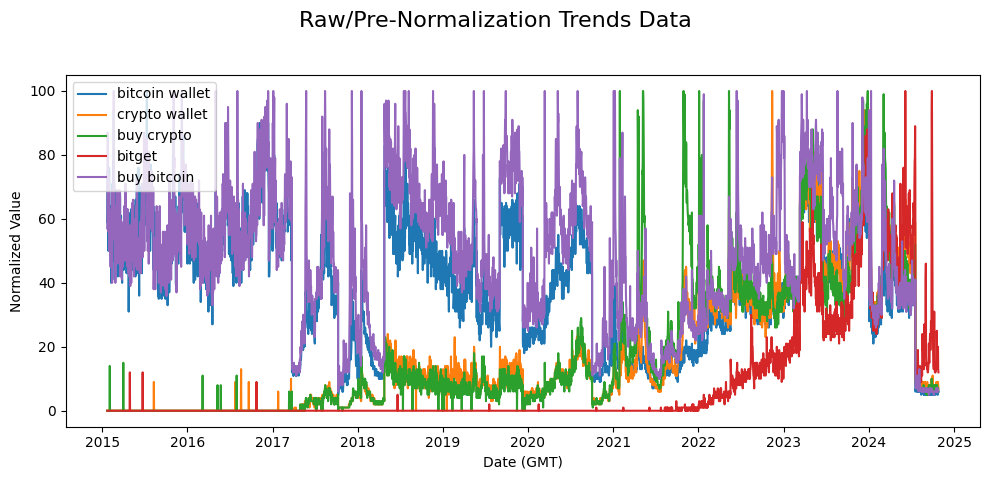

In [3]:
import matplotlib.pyplot as plt

# Define the keyword columns to be normalized
keyword_columns = [
    "bitcoin wallet",
    "crypto wallet",
    "buy crypto",
    "bitget",
    "buy bitcoin"
]

# Create a copy of the DataFrame to avoid modifying the original
df_copy = df.copy()

# Convert date index to MM-DD-YEAR format for GMT on the copy
df_copy.index = pd.to_datetime(df_copy['date_12am_gmt'], format='%m-%d-%Y')

# Plotting all keyword columns together
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Raw/Pre-Normalization Trends Data', fontsize=16)

for col in keyword_columns:
    ax.plot(df_copy.index, df_copy[col], label=col)

ax.set_xlabel('Date (GMT)')
ax.set_ylabel('Normalized Value')
ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


... We clearly see that the pre-normalized data is a mess on a scale from 0 to 100. It is quite different than what [Google shows](https://trends.google.com/trends/explore?date=2015-01-23%202025-01-23&q=bitcoin%20wallet,crypto%20wallet,buy%20crypto,bitget,buy%20bitcoin) for this data (screenshot below):

![Summary preview from Google Trends](preview_from_google.png)

We will now use cumulative scaling to normalize the dataset.

#### Step 3.1: Calculate mean scale factors between neighboring requests

In order to make the normalization possible, we need to first calculate the mean scale factor between neighboring requests. To do so, I made sure that when downloading the data, each request for 100 days of data overlaps with its neighboring (e.g. preceding and succeeding) batches. This way, we can easily compare how each neighboring batch represents the _same day's data_, and use that to calculate a scale factor between the batches.

In [4]:
# Identify duplicate rows based on 'date_12am_gmt' and create a 'duplicate_of' column
# Mark the first occurrence as NaN and subsequent duplicates with the request_id of the first occurrence
df['duplicate_of'] = df.duplicated('date_12am_gmt', keep='first').replace(False, pd.NA)
first_occurrences = df.groupby('date_12am_gmt')['request_id'].transform('first')
df.loc[df['duplicate_of'].notna(), 'duplicate_of'] = first_occurrences
duplicates = df[df.duplicated('date_12am_gmt', keep=False)]
duplicates.head()

,date,bitcoin wallet,crypto wallet,buy crypto,bitget,buy bitcoin,isPartial,epoch_s,date_12am_gmt,request_id,duplicate_of
99,2015-05-02,47,0,0,0,39,False,1430524800,05-02-2015,1,<NA>
100,2015-05-02,47,0,0,0,55,False,1430524800,05-02-2015,2,1
199,2015-08-09,64,0,0,0,68,False,1439078400,08-09-2015,2,<NA>
200,2015-08-09,45,0,0,0,52,False,1439078400,08-09-2015,3,2
299,2015-11-16,47,0,0,0,37,False,1447632000,11-16-2015,3,<NA>


In [5]:
# Function to calculate scale factors between original and duplicate rows
def calculate_scale_factors(df):
    # Create an empty DataFrame to store results
    scale_factors = pd.DataFrame(columns=['date_12am_gmt', 'scale_factor_bitcoin_wallet', 'scale_factor_crypto_wallet', 'scale_factor_buy_crypto', 'scale_factor_bitget', 'scale_factor_buy_bitcoin'])

    # Iterate over each row in the DataFrame
    for index, row in df.iterrows():
        if pd.notna(row['duplicate_of']):
            # Find the original row
            original_row = df[(df['date_12am_gmt'] == row['date_12am_gmt']) & (df['request_id'] == row['duplicate_of'])].iloc[0]
            
            # Calculate scale factors for each keyword column
            scale_factor_bitcoin_wallet = row['bitcoin wallet'] / original_row['bitcoin wallet'] if original_row['bitcoin wallet'] != 0 else None
            scale_factor_crypto_wallet = row['crypto wallet'] / original_row['crypto wallet'] if original_row['crypto wallet'] != 0 else None
            scale_factor_buy_crypto = row['buy crypto'] / original_row['buy crypto'] if original_row['buy crypto'] != 0 else None
            scale_factor_bitget = row['bitget'] / original_row['bitget'] if original_row['bitget'] != 0 else None
            scale_factor_buy_bitcoin = row['buy bitcoin'] / original_row['buy bitcoin'] if original_row['buy bitcoin'] != 0 else None
            
            # Create a new row with the results
            new_row = pd.DataFrame({
                'date_12am_gmt': [row['date_12am_gmt']],
                'scale_factor_bitcoin_wallet': [scale_factor_bitcoin_wallet],
                'scale_factor_crypto_wallet': [scale_factor_crypto_wallet],
                'scale_factor_buy_crypto': [scale_factor_buy_crypto],
                'scale_factor_bitget': [scale_factor_bitget],
                'scale_factor_buy_bitcoin': [scale_factor_buy_bitcoin]
            })
            
            # Concatenate the new row to the scale_factors DataFrame
            scale_factors = pd.concat([scale_factors, new_row], ignore_index=True)

    return scale_factors

# Calculate scale factors for the duplicates DataFrame
scale_factors_df = calculate_scale_factors(duplicates)
scale_factors_df.head()

C:\Users\David\AppData\Local\Temp\ipykernel_17372\3786322210.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scale_factors = pd.concat([scale_factors, new_row], ignore_index=True)


,date_12am_gmt,scale_factor_bitcoin_wallet,scale_factor_crypto_wallet,scale_factor_buy_crypto,scale_factor_bitget,scale_factor_buy_bitcoin
0,05-02-2015,1.000000,NaN,NaN,NaN,1.410256
1,08-09-2015,0.703125,NaN,NaN,NaN,0.764706
2,11-16-2015,1.042553,NaN,NaN,NaN,1.108108
3,02-23-2016,0.830189,NaN,NaN,NaN,0.904762
4,06-01-2016,1.016393,NaN,NaN,NaN,1.075758


In [6]:
# Define scale factor columns
scale_factor_columns = ['scale_factor_bitcoin_wallet', 'scale_factor_crypto_wallet', 'scale_factor_buy_crypto', 'scale_factor_bitget', 'scale_factor_buy_bitcoin']

# Replace zeros with NaN to ignore them in the mean calculation
scale_factors_df[scale_factor_columns] = scale_factors_df[scale_factor_columns].replace(0, pd.NA)

# Calculate the mean of scale factors across the keyword columns for each row, ignoring NaN values
scale_factors_df['mean_scale_factor'] = scale_factors_df[scale_factor_columns].mean(axis=1, skipna=True)

# Create a new DataFrame with only the date and the mean scale factor
mean_scale_factors_df = scale_factors_df[['date_12am_gmt', 'mean_scale_factor']]

# Print the new DataFrame
mean_scale_factors_df.head()

,date_12am_gmt,mean_scale_factor
0,05-02-2015,1.205128
1,08-09-2015,0.733915
2,11-16-2015,1.075331
3,02-23-2016,0.867475
4,06-01-2016,1.046076


The mean scale factor between each neighboring batch of 100 days has been calculated.

#### Step 3.2: Calculate the cumulative scale factor of each request (e.g. 100-day batch) to the first batch

Now that we have a mean scale factor for each request/batch of 100 days' data, we need to calculate the cumulative scale factors. This will be used to scale each batch to the same scale as request 1. Thus, we will end up with a normalized dataset.

With a 0-based index, `mean_scale_factors_df` contains the mean scale factor between `request_id(row N + 2)` and `request_id(row N + 1)`:
$$
\text{mean\_scale\_factor}_N = \frac{\text{request\_id}_{N+2}}{\text{request\_id}_{N+1}}
$$

We need to calculate the cumulative scale factor of any request ID group N to request ID group 1:
$$
\text{cumulative\_scale\_factor}_N = \prod_{i=0}^{N} \frac{1}{\text{mean\_scale\_factor}_i}
$$

In [7]:
# First, invert the scale factors to represent the scaling from N to 1
scale_factors_df['inverse_scale_factor'] = 1 / scale_factors_df['mean_scale_factor']

# Calculate the cumulative product of the inverted scale factors
scale_factors_df['cumulative_scale_factor_to_1'] = np.cumprod(scale_factors_df['inverse_scale_factor'])

# Preview results
scale_factors_df[['date_12am_gmt', 'cumulative_scale_factor_to_1']].head()

,date_12am_gmt,cumulative_scale_factor_to_1
0,05-02-2015,0.829787
1,08-09-2015,1.130631
2,11-16-2015,1.051426
3,02-23-2016,1.212053
4,06-01-2016,1.158667


Cumulative scale factors which scale each batch to request/batch number 1 have been calculated.

#### Step 3.3: Apply the cumulative scale factor to normalize the Trends dataset

Now that we have the cumulative scale factors, we just need to apply them to normalize our data:

In [8]:
# Make a copy of 'df' to avoid modifying it in-place
normalized_df = df.copy()

# Function to retrieve the cumulative factor for a given request_id
def get_cumulative_factor(request_id):
    """
    Returns the cumulative scale factor to scale a row with request_id=N
    back to the group 1 baseline.
    """
    # If request_id is 1, it's the baseline => factor = 1
    if request_id == 1:
        return 1.0
    
    # Otherwise, use the row [N-2] from scale_factors_df
    # (because scale_factors_df starts at request_id=2)
    return scale_factors_df.loc[request_id - 2, 'cumulative_scale_factor_to_1']

# Create a new column in normalized_df for the scaling factor
normalized_df['scaling_factor'] = normalized_df['request_id'].apply(get_cumulative_factor)

# Multiply each keyword column by the appropriate scaling factor
for col in keyword_columns:
    normalized_df[col] = normalized_df[col] * normalized_df['scaling_factor']

# (Optional) Drop the helper column
normalized_df.drop(columns='scaling_factor', inplace=True)

# Now 'normalized_df' contains the normalized keyword columns, while retaining the other original columns.

Finally, we may plot the normalized dataset:

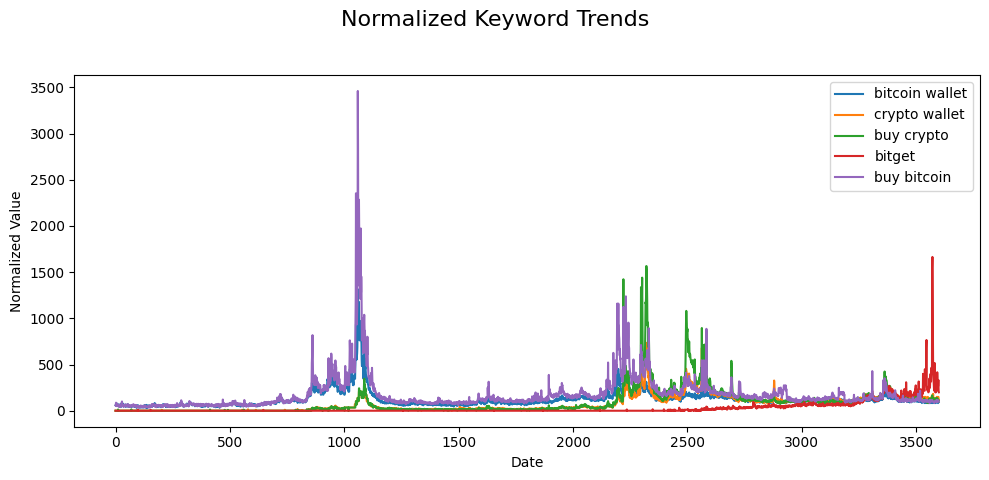

In [9]:
import matplotlib.pyplot as plt

# Plotting all keyword columns together
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Normalized Keyword Trends', fontsize=16)

for col in keyword_columns:
    ax.plot(normalized_df.index, normalized_df[col], label=col)

ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Here is a slightly more smoothed and readable version:

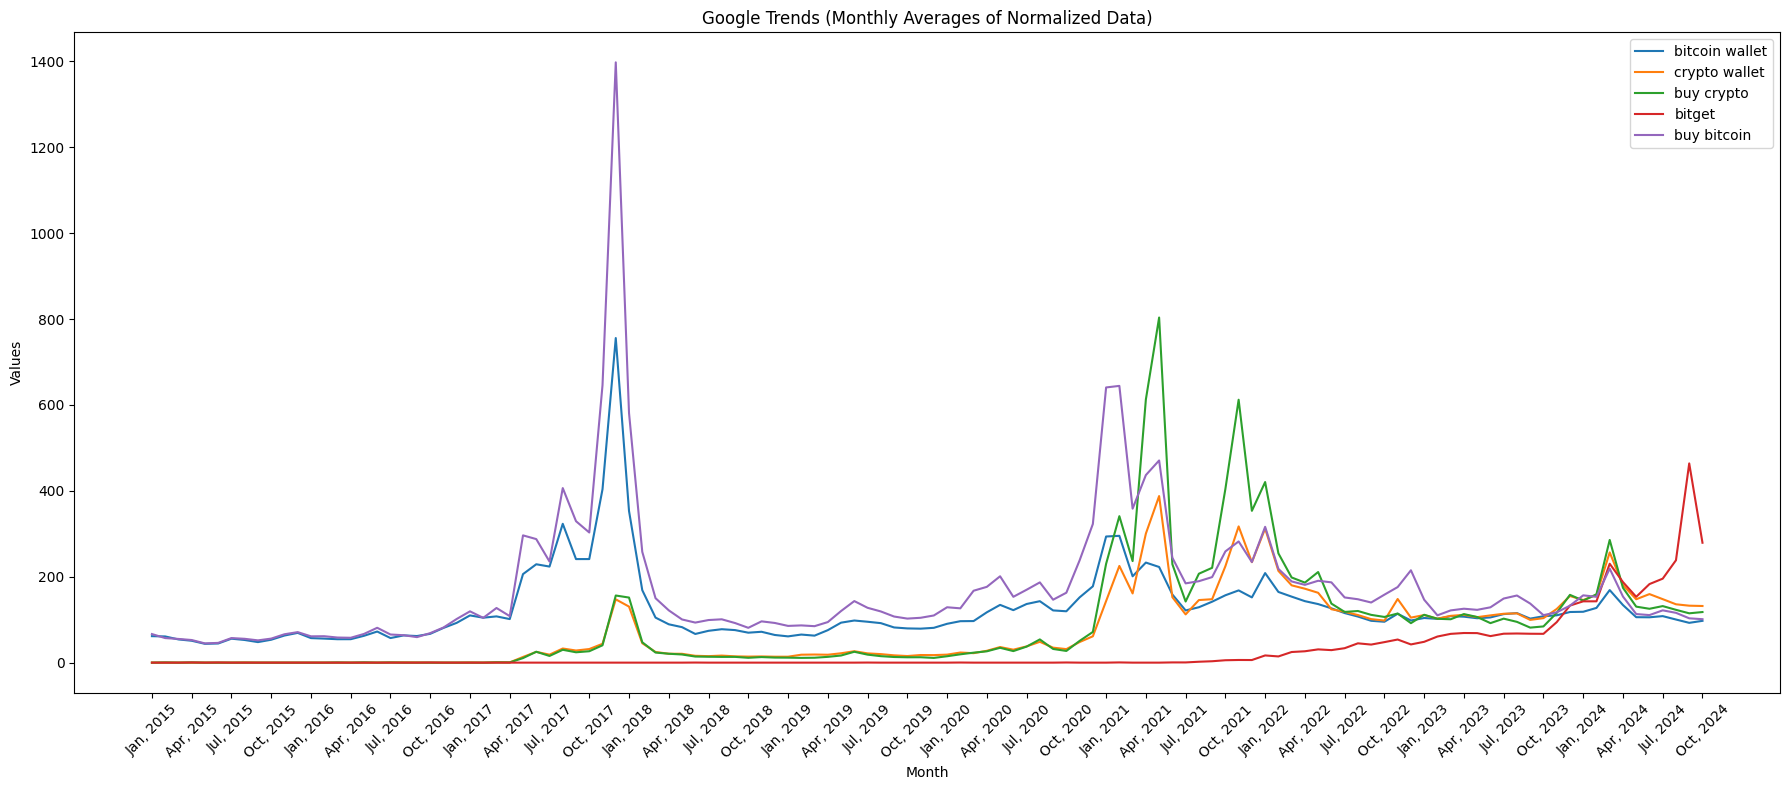

In [10]:
# Ensure the original DataFrame is not modified
temp_df = normalized_df.copy()
temp_df['date_12am_datetime'] = pd.to_datetime(temp_df['date_12am_gmt'])
temp_df['month'] = temp_df['date_12am_datetime'].dt.to_period('M')

# Initialize the plot with a larger figure size
fig, ax = plt.subplots(figsize=(18, 8))  # Increased figure size for a longer graph

# Iterate over the columns to be plotted
for col in keyword_columns:
    monthly_data = temp_df.groupby('month')[col].mean()  # Aggregate by month
    ax.plot(monthly_data.index.astype(str), monthly_data, label=col)

# Customize x-axis ticks to display "Month, Year"
xticks = temp_df['month'].drop_duplicates().sort_values()
xticks_labels = xticks.dt.strftime('%b, %Y')  # Format as "Month, Year"
ax.set_xticks(xticks[::3].astype(str))  # Show every 3rd month
ax.set_xticklabels(xticks_labels[::3], rotation=45)  # Apply custom labels

# Add labels, title, and legend
ax.set_xlabel('Month')
ax.set_ylabel('Values')
ax.set_title('Google Trends (Monthly Averages of Normalized Data)')
ax.legend()

# Show the plot
plt.tight_layout()  # Ensure labels/ticks fit nicely
plt.show()


Compare this to the official plot from Google Trends. (This can be seen above at the top of Step 3 or online [here](https://trends.google.com/trends/explore?date=2015-01-23%202025-01-23&q=bitcoin%20wallet,crypto%20wallet,buy%20crypto,bitget,buy%20bitcoin)).

We finally have a normalized dataset for daily, historic Google Trends data spanning 10 years.

## Clean the normalized Google Trends data

Normalizing the aggregate Google Trends data was a major step of preparing the dataset. However, now it's time to clean it and check its data structure.

First, let's list its columns with data types:

In [11]:
normalized_df.dtypes

date              datetime64[ns]
bitcoin wallet           float64
crypto wallet            float64
buy crypto               float64
bitget                   float64
buy bitcoin              float64
isPartial                   bool
epoch_s                    int64
date_12am_gmt             object
request_id                 int64
duplicate_of              object
dtype: object

We no longer need the temporary columns used for normalizing the data. So, these can be dropped:
- `request_id`
- `date_12am_gmt`
- `duplicate_of`

In [12]:
cleaned_df = normalized_df.copy()
cleaned_df.drop(columns=['request_id', 'date_12am_gmt', 'duplicate_of'], inplace=True)
cleaned_df.columns.values

array(['date', 'bitcoin wallet', 'crypto wallet', 'buy crypto', 'bitget',
       'buy bitcoin', 'isPartial', 'epoch_s'], dtype=object)

It seems that `epoch_s` is redundant, since we have the preferred `datetime`-type `date` column. Let's ensure that it's a duplicate first:

In [13]:
# Display the head of cleaned_df with only 'date' and 'epoch_s' columns
display(cleaned_df[['date', 'epoch_s']].head())

# Make a copy of the dataframe and convert 'date' to epoch seconds
print("Convert `date` to epoch (s):")
df_copy = cleaned_df.copy()
df_copy['date'] = df_copy['date'].astype('int64') // 10**9  # Convert datetime to epoch seconds
display(df_copy[['date', 'epoch_s']].head())


,date,epoch_s
0,2015-01-23,1421971200
1,2015-01-24,1422057600
2,2015-01-25,1422144000
3,2015-01-26,1422230400
4,2015-01-27,1422316800


Convert `date` to epoch (s):


,date,epoch_s
0,1421971200,1421971200
1,1422057600,1422057600
2,1422144000,1422144000
3,1422230400,1422230400
4,1422316800,1422316800


`epoch_s` is indeed redundant, so I'll drop it:

In [14]:
cleaned_df.drop(columns=['epoch_s'], inplace=True)

According to `pytrends` docs, the `bool` column, `isPartial` will only be `True` for rows that Google indicates have incomplete data. This is usually the case when collecting the current day's data, but should otherwise be `False`. Let's check it in our dataset:

In [15]:
# Count how many 'isPartial' values are True
false_count = cleaned_df['isPartial'].eq(True).sum()
print("Number of True values in `isPartial`:", false_count)

Number of True values in `isPartial`: 0


`isPartial` is always `False` in our dataset, as expected. In this case, since it has no other significance, it can be dropped:

In [16]:
cleaned_df.drop(columns=['isPartial'], inplace=True)

In [17]:
cleaned_df.dtypes

date              datetime64[ns]
bitcoin wallet           float64
crypto wallet            float64
buy crypto               float64
bitget                   float64
buy bitcoin              float64
dtype: object

We now have a cleaned Google Trends dataset spanning 10 years for our 5 keywords of interest. This should suffice for modeling tasks in the next milestone.

## Historic BTC price data

Yahoo Finance is a reliable source of financial data. It also returns data in UTC - which matches the time zone of my Google Trends dataset. I will use the `yfinance` package to download historical Bitcoin data for our 10-year range under study (January 23, 2015 to January 23, 2025):

In [143]:
# Import yfinance
import yfinance as yf

# Define time period
start_date = datetime.strptime('2015-01-23', '%Y-%m-%d')
end_date = datetime.strptime('2025-01-24', '%Y-%m-%d')

# Download the data
btc_data = yf.download('BTC-USD', start=start_date, end=end_date)
btc_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-23,232.878998,234.845001,225.195999,233.516998,24621700
2015-01-24,247.847000,248.210007,230.022003,232.699997,24782500
2015-01-25,253.718002,255.074005,243.889999,247.352005,33582700
2015-01-26,273.472992,309.384003,254.078995,254.078995,106794000
2015-01-27,263.475006,275.480011,250.653000,273.166992,44399000


### Cleaning the BTC data

Before cleaning, I'll check the data types:

In [144]:
btc_data.dtypes

Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object

It looks like the `Date` column is the index, which is why it isn't showing up in the above output. I'm going to change that, since we will soon merge this with the Google Trends dataset and use a single `Date` column then.

In [145]:
# Check the data's index:
btc_data.index

DatetimeIndex(['2015-01-23', '2015-01-24', '2015-01-25', '2015-01-26',
               '2015-01-27', '2015-01-28', '2015-01-29', '2015-01-30',
               '2015-01-31', '2015-02-01',
               ...
               '2025-01-14', '2025-01-15', '2025-01-16', '2025-01-17',
               '2025-01-18', '2025-01-19', '2025-01-20', '2025-01-21',
               '2025-01-22', '2025-01-23'],
              dtype='datetime64[ns]', name='Date', length=3654, freq=None)

In [146]:
# Reset the index:
btc_data.reset_index(inplace=True)
btc_data.dtypes

Price   Ticker 
Date               datetime64[ns]
Close   BTC-USD           float64
High    BTC-USD           float64
Low     BTC-USD           float64
Open    BTC-USD           float64
Volume  BTC-USD             int64
dtype: object

Next, I'm going to check if the data has any missing values:

In [147]:
# Check for missing values in each column
missing_values = btc_data.isnull().sum()

# Print the result
print("Missing values in BTC dataset:")
print(missing_values)

Missing values in BTC dataset:
Price   Ticker 
Date               0
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64


The above output shows 0 missing values across all columns. Next, I will check the column structure:

In [148]:
btc_data.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

I will clean the data some more, by removing the `Ticker` MultiIndex, since we know that we are only dealing with Bitcoin and prices in USD:

In [149]:
# Flatten the MultiIndex by selecting the second level which contains the actual data labels
btc_data.columns = btc_data.columns.get_level_values(0)
btc_data.dtypes

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Now, the Bitcoin data is cleaned, formatted, and ready for further processing.

### Feature engineering and label creation

The cleaned bitcoin data can be a lot more useful for predictive modeling with feature engineering. For now, I'd like to introduce:
- Daily percentage change (`pct_change_1d`)
- 3-Day moving average (`sma_3d`)
- d-Day volatility (`volatility_3d`)

Daily percentage change indicates if the price went up or down from one day to the next, and by how much. The 3-day moving average caputres smoothed out price trends, reducing noise from daily changes. Finally, the 3-day volatility feature can help a model distinguish stable conditions versus unpredictable ones.

I'll be using the closing price to represent each day's price.

In [150]:
# Calculate and store the daily percentage change in price
btc_data['pct_change_1d'] = btc_data['Close'].pct_change(1)

# Calculate and store the 3-day simple moving average of price
btc_data['sma_3d'] = btc_data['Close'].rolling(window=3).mean()

# Calculate the 3-day rolling standard deviation of the daily percentage change in price, representing volatility
btc_data['volatility_3d'] = btc_data['Close'].pct_change().rolling(3).std()

btc_data.head()

Price,Date,Close,High,Low,Open,Volume,pct_change_1d,sma_3d,volatility_3d
0,2015-01-23,232.878998,234.845001,225.195999,233.516998,24621700,NaN,NaN,NaN
1,2015-01-24,247.847000,248.210007,230.022003,232.699997,24782500,0.064274,NaN,NaN
2,2015-01-25,253.718002,255.074005,243.889999,247.352005,33582700,0.023688,244.814667,NaN
3,2015-01-26,273.472992,309.384003,254.078995,254.078995,106794000,0.077862,258.345998,0.028186
4,2015-01-27,263.475006,275.480011,250.653000,273.166992,44399000,-0.036559,263.555333,0.057238


Next, I'd like to create the target column for classification.

In my case, I want to use past price movements and Google Trends data to forecast Bitcoin's closing price change one day in advance. Therefore, I will create a binary column which represents, "Will price go up tomorrow?" and call it `price_up_tomorrow`:

In [151]:
btc_data["Price_up_tomorrow"] = (btc_data["Close"].shift(-1) > btc_data["Close"]).astype(int)
btc_data.head()

Price,Date,Close,High,Low,Open,Volume,pct_change_1d,sma_3d,volatility_3d,Price_up_tomorrow
0,2015-01-23,232.878998,234.845001,225.195999,233.516998,24621700,NaN,NaN,NaN,1
1,2015-01-24,247.847000,248.210007,230.022003,232.699997,24782500,0.064274,NaN,NaN,1
2,2015-01-25,253.718002,255.074005,243.889999,247.352005,33582700,0.023688,244.814667,NaN,1
3,2015-01-26,273.472992,309.384003,254.078995,254.078995,106794000,0.077862,258.345998,0.028186,0
4,2015-01-27,263.475006,275.480011,250.653000,273.166992,44399000,-0.036559,263.555333,0.057238,0


Lastly, I need to correct `Price_up_tomorrow` for the first row, by checking it against the previous day:

In [152]:
# Create temporary start and end dates for fetching the previous day's data
temp_end_date = start_date
temp_start_date = temp_end_date - pd.Timedelta(days=1)

prior_data = yf.download('BTC-USD', start=temp_start_date, end=temp_end_date)

print("Fetched data:\n", prior_data)
print("\nDay prior to dataset's start date, closing price:\n", prior_data['Close'])

[*********************100%***********************]  1 of 1 completed

Fetched data:
 Price            Close        High         Low        Open    Volume
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
Date                                                                
2015-01-22  233.406006  237.018997  226.434006  227.322006  33544600

Day prior to dataset's start date, closing price:
 Ticker         BTC-USD
Date                  
2015-01-22  233.406006


It looks like the price went down from January 22nd to 23rd (2015), so our dataset's first row should have `Price_up_tomorrow=0`:

In [153]:
btc_data.loc[0, "Price_up_tomorrow"] = int(btc_data.loc[0, "Close"] > prior_data.iloc[0]["Close"])
btc_data.head()

C:\Users\David\AppData\Local\Temp\ipykernel_17372\2676429049.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  btc_data.loc[0, "Price_up_tomorrow"] = int(btc_data.loc[0, "Close"] > prior_data.iloc[0]["Close"])


Price,Date,Close,High,Low,Open,Volume,pct_change_1d,sma_3d,volatility_3d,Price_up_tomorrow
0,2015-01-23,232.878998,234.845001,225.195999,233.516998,24621700,NaN,NaN,NaN,0
1,2015-01-24,247.847000,248.210007,230.022003,232.699997,24782500,0.064274,NaN,NaN,1
2,2015-01-25,253.718002,255.074005,243.889999,247.352005,33582700,0.023688,244.814667,NaN,1
3,2015-01-26,273.472992,309.384003,254.078995,254.078995,106794000,0.077862,258.345998,0.028186,0
4,2015-01-27,263.475006,275.480011,250.653000,273.166992,44399000,-0.036559,263.555333,0.057238,0


### Final cleaning

Finally, I'd like to drop columns which I don't plan to use in my model. This includes all columns except 'Date', 'Close', and the engineered features. 

In [156]:
# Define array of columns I'd like to keep
columns_to_keep = ['Date', 'Close', 'pct_change_1d', 'sma_3d', 'volatility_3d', 'Price_up_tomorrow']

# Store new cleaned dataframe, with only the desired columns
btc_data_cleaned = btc_data[columns_to_keep]

btc_data_cleaned

Price,Date,Close,pct_change_1d,sma_3d,volatility_3d,Price_up_tomorrow
0,2015-01-23,232.878998,NaN,NaN,NaN,0
1,2015-01-24,247.847000,0.064274,NaN,NaN,1
2,2015-01-25,253.718002,0.023688,244.814667,NaN,1
3,2015-01-26,273.472992,0.077862,258.345998,0.028186,0
4,2015-01-27,263.475006,-0.036559,263.555333,0.057238,0
...,...,...,...,...,...,...
3649,2025-01-19,101089.609375,-0.031784,103319.906250,0.039758,1
3650,2025-01-20,102016.664062,0.009171,102504.781250,0.021404,1
3651,2025-01-21,106146.265625,0.040480,103084.179688,0.036239,0
3652,2025-01-22,103653.070312,-0.023488,103938.666667,0.031986,1


## Closing remarks

By the end of Milestone 2, I have two complete, mergable datasets for Google Trends and Bitcoin spanning 10 years.

The Google Trends data had to undergo a lot of processing to reach a normalized and usable dataset. The Bitcoin data was a bit easier to work with and I engineered 3 new features plus the target column, which I hope will be useful for model building in the next milestone.